# FIT5196 Assessment 1 — Task 5 focused EDA

**Group:** Group050  
**Team members:** Xingao Zhan (36354775); Yu Wang (26900867); Keshu Zhang (36436763); Qingzhuo Zhao (26662841)  
**Scope of this notebook version:** Lucy's assessed **Figure 1** and **Figure 2**, based on the standardised `orders` and `order_items` outputs.

The two figures form a focused sequence: first describe the distribution of completed-order value, then examine how order value differs with the number of units in the basket.

## 0. Configuration, loading and grain checks

The path detection below supports running the notebook either from its own folder or from the assignment root. The checks establish the primary-key grains and aggregate `order_items` to one row per order before joining. This is the explicit safeguard against inflating order-level amounts through a one-to-many join.

In [1]:
from pathlib import Path
import os
import tempfile

# Keep Matplotlib's cache in a writable temporary location.
os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "group050-matplotlib-cache"),
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import display

GROUP_ID = "Group050"
ORDER_FILE = f"{GROUP_ID}_orders_standardised.csv"
ITEM_FILE = f"{GROUP_ID}_order_items_standardised.csv"

candidate_roots = [
    Path.cwd(),
    Path.cwd() / "大家写的答案",
    Path.cwd().parent / "大家写的答案",
]

for candidate in candidate_roots:
    if (candidate / "outputs" / ORDER_FILE).exists():
        PROJECT_DIR = candidate.resolve()
        break
else:
    raise FileNotFoundError(
        "Could not locate the standardised outputs. Run this notebook from "
        "the assignment root or the 大家写的答案 folder."
    )

OUTPUT_DIR = PROJECT_DIR / "outputs"
FIGURE_DIR = PROJECT_DIR / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

orders = pd.read_csv(OUTPUT_DIR / ORDER_FILE, keep_default_na=False)
order_items = pd.read_csv(OUTPUT_DIR / ITEM_FILE, keep_default_na=False)

orders["order_total"] = pd.to_numeric(orders["order_total"], errors="raise")
order_items["quantity"] = pd.to_numeric(
    order_items["quantity"], errors="raise"
)
order_items["line_revenue"] = pd.to_numeric(
    order_items["line_revenue"], errors="raise"
)

assert orders["order_id"].is_unique, "orders must be one row per order_id"
assert order_items["order_item_id"].is_unique, (
    "order_items must be one row per order_item_id"
)
assert orders["order_id"].notna().all()
assert order_items[["order_item_id", "order_id"]].notna().all().all()

# Aggregate the many-side before the join: one row per order_id.
order_baskets = (
    order_items.groupby("order_id", as_index=False)
    .agg(
        total_units=("quantity", "sum"),
        line_count=("order_item_id", "size"),
        item_subtotal=("line_revenue", "sum"),
    )
)

missing_item_orders = set(order_baskets["order_id"]) - set(orders["order_id"])
orders_without_items = set(orders["order_id"]) - set(order_baskets["order_id"])
assert not missing_item_orders, "Some order_items do not match an order"
assert not orders_without_items, "Some orders have no order_items"

order_analysis = orders.merge(
    order_baskets,
    on="order_id",
    how="inner",
    validate="one_to_one",
)

assert len(order_analysis) == len(orders)
assert np.allclose(
    order_analysis["item_subtotal"],
    pd.to_numeric(order_analysis["order_price"]),
    atol=0.01,
)

join_check = pd.DataFrame(
    {
        "check": [
            "orders rows / unique order_id",
            "order_items rows / unique order_item_id",
            "order-level basket rows",
            "rows after validated one-to-one join",
            "unmatched orders on either side",
            "item subtotal vs order_price mismatches (> A$0.01)",
        ],
        "observed": [
            f"{len(orders):,} / {orders['order_id'].nunique():,}",
            f"{len(order_items):,} / {order_items['order_item_id'].nunique():,}",
            f"{len(order_baskets):,}",
            f"{len(order_analysis):,}",
            len(missing_item_orders) + len(orders_without_items),
            int(
                (
                    order_analysis["item_subtotal"]
                    - pd.to_numeric(order_analysis["order_price"])
                ).abs().gt(0.01).sum()
            ),
        ],
        "status": ["PASS"] * 6,
    }
)

display(join_check)
print(f"Output directory: {OUTPUT_DIR}")
print(f"Figure directory: {FIGURE_DIR}")

,check,observed,status
0,orders rows / unique order_id,"5,000 / 5,000",PASS
1,order_items rows / unique order_item_id,"15,711 / 15,711",PASS
2,order-level basket rows,"5,000",PASS
3,rows after validated one-to-one join,"5,000",PASS
4,unmatched orders on either side,0,PASS
5,item subtotal vs order_price mismatches (> A$0...,0,PASS


Output directory: /Users/Lucy/Desktop/2026 S2/FIT5196/assignment/大家写的答案/outputs
Figure directory: /Users/Lucy/Desktop/2026 S2/FIT5196/assignment/大家写的答案/figures


### Figure 1: Univariate distribution of completed-order value

**Analytical question:** How are completed order totals distributed, and where does the high-value tail begin?  
**Observation unit and denominator:** One completed order; all **5,000** rows in `orders`. The monetary unit is Australian dollars (AUD).  
**Tables and join keys:** `orders` only; no join. `order_id` is the checked primary key.  
**Chart choice:** A histogram is appropriate for the distribution of a continuous monetary variable. Median and 90th-percentile reference lines make the centre and upper tail readable without treating the skewed mean as a typical order.  
**Result:** The distribution is right-skewed. The median order total is **A$2,491.42**, the middle 50% spans **A$1,449.17–A$3,951.42**, and the 90th percentile is **A$5,702.77**. Thus, 10% of completed orders exceed approximately A$5.7k.  
**Material limitation:** The table contains completed orders only, so the distribution does not describe cancelled or abandoned demand. `order_total` also combines merchandise, tax, delivery and discounts; this figure alone cannot identify which component or product mix creates the high-value tail.

,Figure 1 summary
orders (n),5000.000
median (AUD),2491.420
Q1 (AUD),1449.170
Q3 (AUD),3951.415
90th percentile (AUD),5702.772
maximum (AUD),15217.950


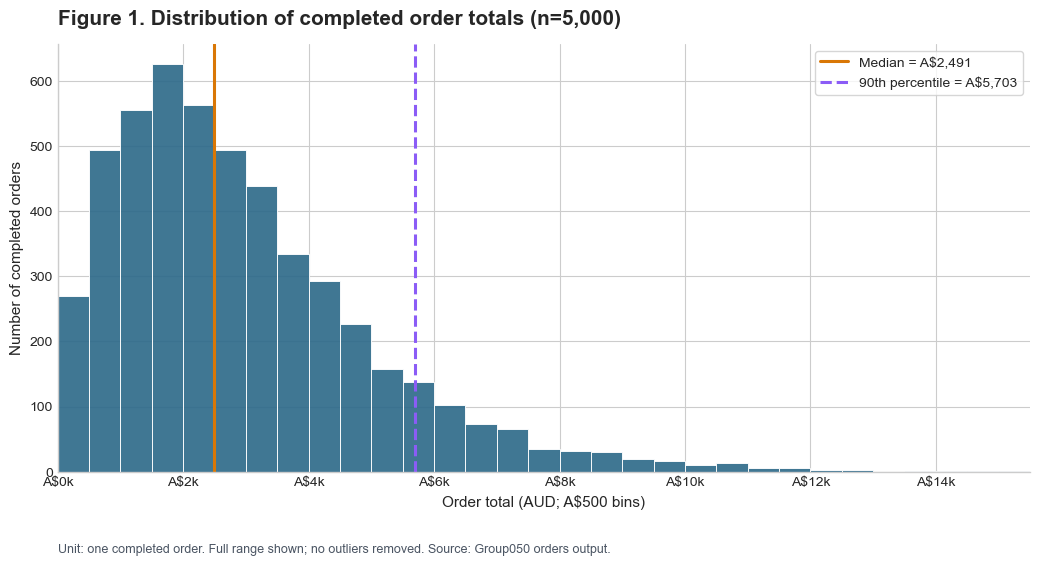

Saved: /Users/Lucy/Desktop/2026 S2/FIT5196/assignment/大家写的答案/figures/Figure 1.png


In [2]:
# Figure 1 — distribution of order_total at the one-order grain
order_total = order_analysis["order_total"]
median_total = order_total.median()
q1_total = order_total.quantile(0.25)
q3_total = order_total.quantile(0.75)
p90_total = order_total.quantile(0.90)

summary_figure_1 = pd.Series(
    {
        "orders (n)": len(order_total),
        "median (AUD)": median_total,
        "Q1 (AUD)": q1_total,
        "Q3 (AUD)": q3_total,
        "90th percentile (AUD)": p90_total,
        "maximum (AUD)": order_total.max(),
    },
    name="Figure 1 summary",
)
display(summary_figure_1.to_frame())

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(10.5, 5.8))

# A$500 bins give a stable, interpretable view of the full untrimmed range.
upper_edge = int(np.ceil(order_total.max() / 500) * 500) + 500
bins = np.arange(0, upper_edge + 1, 500)
ax.hist(
    order_total,
    bins=bins,
    color="#2F6B8A",
    edgecolor="white",
    linewidth=0.7,
    alpha=0.92,
)

ax.axvline(
    median_total,
    color="#D97706",
    linewidth=2.2,
    label=f"Median = A${median_total:,.0f}",
)
ax.axvline(
    p90_total,
    color="#8B5CF6",
    linewidth=2.2,
    linestyle="--",
    label=f"90th percentile = A${p90_total:,.0f}",
)

ax.set_title(
    "Figure 1. Distribution of completed order totals (n=5,000)",
    loc="left",
    fontsize=15,
    fontweight="bold",
    pad=14,
)
ax.set_xlabel("Order total (AUD; A$500 bins)", fontsize=11)
ax.set_ylabel("Number of completed orders", fontsize=11)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"A${x/1000:.0f}k"))
ax.set_xlim(0, upper_edge - 500)
ax.legend(frameon=True, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
ax.text(
    0,
    -0.19,
    "Unit: one completed order. Full range shown; no outliers removed. Source: Group050 orders output.",
    transform=ax.transAxes,
    fontsize=9,
    color="#4B5563",
)

fig.tight_layout()
figure_1_path = FIGURE_DIR / "Figure 1.png"
fig.savefig(figure_1_path, dpi=220, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {figure_1_path}")

### Figure 2: Bivariate relationship between basket units and order total

**Analytical question:** How does completed order total differ as the number of units in the basket increases?  
**Observation unit and denominator:** One completed order; all **5,000** orders with at least one matched order item. `total_units` is the sum of `quantity` within each `order_id`; the 8+ group pools 143 orders with 8–12 units.  
**Tables and join keys:** `order_items` is first aggregated by `order_id`, then joined to `orders` on `order_id` with `validate='one_to_one'`. The row-count check confirms **5,000 orders before and after the join**, so order totals are not duplicated.  
**Chart choice:** Box plots compare the full order-total distribution across discrete basket-size groups; boxes show the median and interquartile range while suppressing individual outlier points that would obscure the group comparison. Sample sizes and medians are labelled.  
**Result:** Order total increases monotonically with basket size: the median rises from **A$551.08** for one-unit orders to **A$5,245.05** for orders with 8+ units. The rank correlation is **Spearman ρ = 0.634**, indicating a moderately strong positive association, but the wide within-group spreads show that unit price and product mix also matter.  
**Material limitation:** This is descriptive, not causal, and part of the association is mechanical because more purchased units contribute to order value. The comparison does not control for product category, unit price, discounts, tax or delivery charges; additionally, the 8+ group combines several sparse basket sizes.

,orders,median_AUD,Q1_AUD,Q3_AUD
unit_group,,,,
1,324,551.08,283.39,1022.62
2,644,1281.20,769.13,1951.54
3,1082,1876.55,1207.88,2826.41
4,1114,2706.27,1804.66,3748.48
5,862,3350.99,2321.93,4707.67
6,543,3724.96,2732.98,5308.02
7,288,4728.74,3368.86,6206.25
8+,143,5245.05,3916.89,7702.93


Spearman rank correlation: 0.634


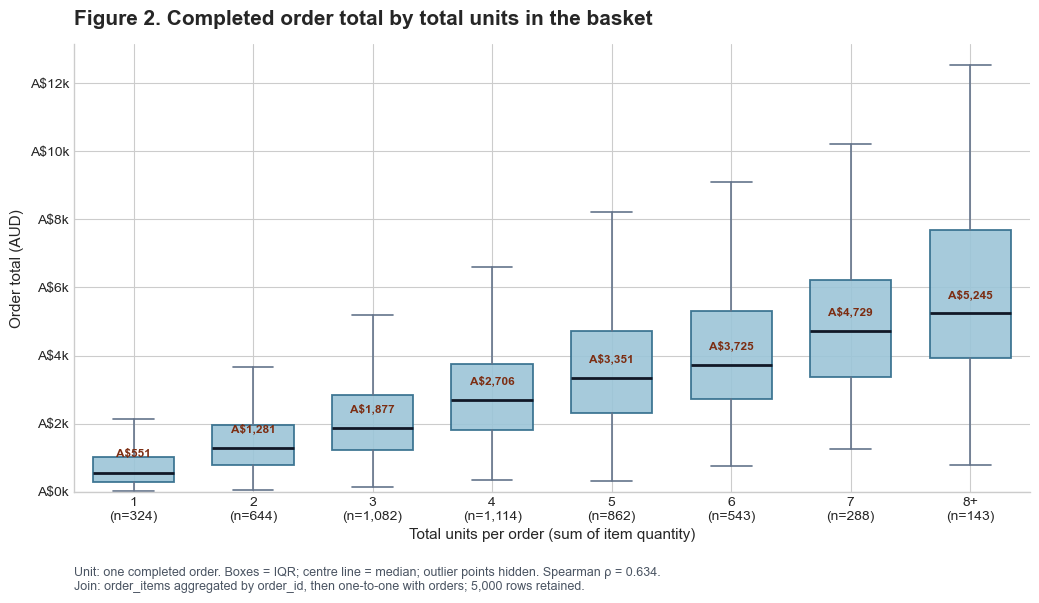

Saved: /Users/Lucy/Desktop/2026 S2/FIT5196/assignment/大家写的答案/figures/Figure 2.png


In [3]:
# Figure 2 — aggregate order_items first, then compare at one-order grain
order_analysis["unit_group"] = order_analysis["total_units"].astype(int).astype(str)
order_analysis.loc[order_analysis["total_units"] >= 8, "unit_group"] = "8+"

group_order = ["1", "2", "3", "4", "5", "6", "7", "8+"]
grouped_totals = [
    order_analysis.loc[
        order_analysis["unit_group"].eq(group), "order_total"
    ].to_numpy()
    for group in group_order
]

group_summary = (
    order_analysis.groupby("unit_group")["order_total"]
    .agg(
        orders="size",
        median_AUD="median",
        Q1_AUD=lambda s: s.quantile(0.25),
        Q3_AUD=lambda s: s.quantile(0.75),
    )
    .reindex(group_order)
)

# Rank-based correlation, computed without an external statistics dependency.
spearman_rho = order_analysis["total_units"].rank(method="average").corr(
    order_analysis["order_total"].rank(method="average")
)

display(group_summary.round(2))
print(f"Spearman rank correlation: {spearman_rho:.3f}")

fig, ax = plt.subplots(figsize=(10.5, 6.2))
box = ax.boxplot(
    grouped_totals,
    patch_artist=True,
    showfliers=False,
    widths=0.68,
    medianprops={"color": "#111827", "linewidth": 2.0},
    boxprops={"edgecolor": "#2F6B8A", "linewidth": 1.3},
    whiskerprops={"color": "#64748B", "linewidth": 1.2},
    capprops={"color": "#64748B", "linewidth": 1.2},
)

for patch in box["boxes"]:
    patch.set_facecolor("#9CC5D8")
    patch.set_alpha(0.9)

counts = group_summary["orders"].astype(int)
medians = group_summary["median_AUD"]
tick_labels = [
    f"{group}\n(n={counts.loc[group]:,})" for group in group_order
]
ax.set_xticks(range(1, len(group_order) + 1), tick_labels)

for x_position, group in enumerate(group_order, start=1):
    median_value = medians.loc[group]
    ax.annotate(
        f"A${median_value:,.0f}",
        xy=(x_position, median_value),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8.5,
        fontweight="bold",
        color="#7C2D12",
    )

ax.set_title(
    "Figure 2. Completed order total by total units in the basket",
    loc="left",
    fontsize=15,
    fontweight="bold",
    pad=14,
)
ax.set_xlabel("Total units per order (sum of item quantity)", fontsize=11)
ax.set_ylabel("Order total (AUD)", fontsize=11)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"A${y/1000:.0f}k"))
ax.set_ylim(bottom=0)
ax.spines[["top", "right"]].set_visible(False)
ax.text(
    0,
    -0.22,
    (
        f"Unit: one completed order. Boxes = IQR; centre line = median; outlier points hidden. "
        f"Spearman ρ = {spearman_rho:.3f}.\n"
        "Join: order_items aggregated by order_id, then one-to-one with orders; 5,000 rows retained."
    ),
    transform=ax.transAxes,
    fontsize=9,
    color="#4B5563",
)

fig.tight_layout()
figure_2_path = FIGURE_DIR / "Figure 2.png"
fig.savefig(figure_2_path, dpi=220, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {figure_2_path}")

## Handoff note for the team notebook

These are the two assessed visualisations allocated to the `orders` / `order_items` contribution. When merging with the team's remaining Task 5 work, preserve the **Figure 1** and **Figure 2** labels and retain the grain/join check above. Figures 3–6 should cover the remaining four required categories and bring the collective evidence to at least four standardised output tables and two valid relational analyses.